# Section 4 Computing the Jacobian for heterogeneous-agent blocks

Issues/questions? Email Martin Aragoneses [maragoneses@g.harvard.edu]

Based on notebook accompanying the working paper Auclert, Bardóczy, Rognlie, Straub (2019): "Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models", which can be found in [Github repository](https://github.com/shade-econ/sequence-jacobian)

This builds on the current public code in the 2019 SHADE repo which is a little sparse on the intuition behind each step, so I go through it in a bit of detail to help you digest it (in particular, pasting the functions that are doing each step under the hood for you to inspect). The main issue is that this is based on the 2019 version of their repo, which uses some older notation. Ludwig posted last night in Canvas the new 2021 version with the same notation we are using for the class, with code that runs all graphs in the lecture slides. You should definitely check those out! 

For some more intuition + math check the new version of the paper + the notes on SSJ I covered in the last section.

## 0 Import packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import hank
import seaborn as sns

## 1 Getting the sequence-space Jacobian: fake news algorithm
In this notebook, we will use our one-asset HANK model as an example to work through the fake news algorithm that is implemented in our codebase. (Please see the `hank.ipynb` notebook for more details about this model.)


$$
\begin{align} \tag{HH}
V_t(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \sum_{e'}V_{t+1}(e', a) \mathcal{P}(e,e') \right\}
\\
c + a &= (1 + r_t)a_{-} + w_t e n - \tau_t \bar{\tau}(e) + d_t \bar{d}(e)
\\
a &\geq 0
\end{align}
$$

Thus, $c,a,n = household(r,w,d,\tau)$. Then, given $D$ we can compute four aggregates, $C,A,N,NS$ where $NS$ weights by effective labor supply.


First, we calculate the steady state and load the household HetBlock ("heterogeneous agent block"), with the function determining transfers attached, from the `hank.py` module.

In [4]:
ss = hank.hank_ss() # calculate Steady State

household = hank.household_trans
# Note that household_trans = household.attach_hetinput(transfers) and household = hank.household block 


print(ss['D'].shape)


(7, 500)


### 1.1 Automatic implementation of fake-news method
Now, we can immediately get the Jacobian with respect to all aggregate inputs that might change: `w`, `r`, dividends `Div`, and lump-sum taxes `Tax`, by using the `jac` method of the `household` HetBlock.

In [5]:
T = 300
shock_list = ['w', 'r', 'Div', 'Tax'] # Inputs to shock in the jacobian

Js = household.jac(ss, T, shock_list) # Js = {"output": {"input": J_output_input}}
Js

{'NS': {'w': array([[ 4.75955756e-01, -3.37933959e-02, -3.07581116e-02, ...,
          -4.05937384e-08, -3.87153565e-08, -3.69237904e-08],
         [-3.36466084e-02,  4.80411843e-01, -3.10848570e-02, ...,
          -4.14961491e-08, -3.95759203e-08, -3.77446299e-08],
         [-3.04763599e-02, -3.09956808e-02,  4.82898213e-01, ...,
          -4.24882870e-08, -4.05221393e-08, -3.86469738e-08],
         ...,
         [-3.31864263e-06, -3.32081856e-06, -3.32769924e-06, ...,
           4.97254067e-01, -1.59721938e-02, -1.49646645e-02],
         [-3.22232981e-06, -3.22444211e-06, -3.23112259e-06, ...,
          -1.57973231e-02,  4.97254067e-01, -1.59721938e-02],
         [-3.12881231e-06, -3.13086285e-06, -3.13734897e-06, ...,
          -1.45704712e-02, -1.57973231e-02,  4.97254067e-01]]),
  'r': array([[-7.84819686e-02,  3.45695489e-01,  3.25762342e-01, ...,
           4.41614292e-07,  4.21180969e-07,  4.01693307e-07],
         [-7.62645569e-02, -9.62177434e-02,  3.30558990e-01, ...,
      

`Js` is a nested dict, with keys on the first level being aggregate outputs:

In [6]:
Js.keys()


dict_keys(['NS', 'N', 'C', 'A'])

Note that we have Jacobians for four outputs: assets `A`, consumption `C`, labor `N`, and skill-weighted labor `NS` (which is the effective labor provided to firms).

We have these four outputs since we did not specify a list of outputs, and the default of the `jac` function is to calculate Jacobians for all outputs reported by the HetBlock (i.e. **all outputs of the underlying function `hank.household()`**).

For each output—for instance, assets `A`—we have Jacobians for all four inputs we asked about.

In [7]:
Js['A'].keys()

dict_keys(['w', 'r', 'Div', 'Tax'])

In total, this means that the code calculated 16 Jacobians, for each pair of 4 aggregate outputs and 4 aggregate inputs, each of which is 300-by-300, e.g.

<AxesSubplot:>

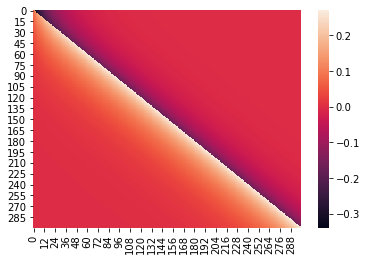

In [8]:
Js['C']['r'].shape

sns.heatmap(Js['C']['r'])


As usual, we can interpret column $s$ Jacobian of some output with respect to an input as giving the impulse response of the output to a "news shock" at date 0 that the input will change at date $s$.

Let's plot some columns $s=4,8,12,16,20$ of the Jacobian of $C$ vs. $r$, giving the impulse responses of consumption to news about the real interest rate at different dates.

In [9]:
Js['C']['w'][:4, :4]

array([[0.11834767, 0.03310849, 0.03024876, 0.02805957],
       [0.03302557, 0.1139897 , 0.03041878, 0.0282187 ],
       [0.0301323 , 0.0304145 , 0.11153409, 0.02849067],
       [0.02809133, 0.02814476, 0.02849658, 0.10973226]])

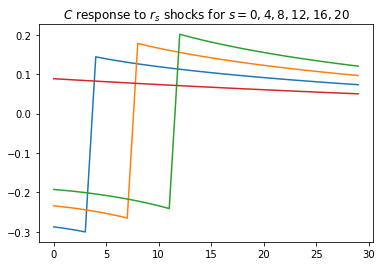

In [10]:
plt.plot(Js['C']['r'][:30, [4, 8, 12]])
plt.plot(Js['C']['r'][:30, 0])

plt.title('$C$ response to $r_s$ shocks for $s=0, 4,8,12,16,20$');

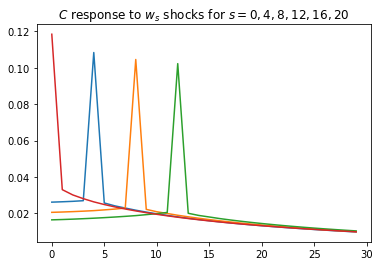

In [11]:
plt.plot(Js['C']['w'][:30, [4, 8, 12]])
plt.plot(Js['C']['w'][:30, 0])

plt.title('$C$ response to $w_s$ shocks for $s=0, 4,8,12,16,20$');

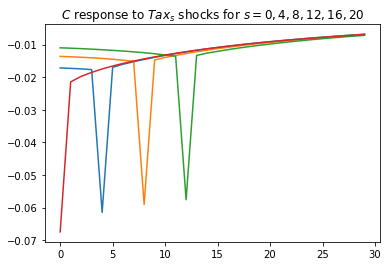

In [12]:
plt.plot(Js['C']['Tax'][:30, [4, 8, 12]])
plt.plot(Js['C']['Tax'][:30, 0])

plt.title('$C$ response to $Tax_s$ shocks for $s=0, 4,8,12,16,20$');

In response to a news shock $r_s$, consumption always jumps up between $s-1$ and $s$, consistent with the Euler equation ($r_s$ is defined to be the ex-post rate paid on savings between $s-1$ and $s$). 

That is, before the shock takes place, households expect to want to save a lot in anticipation of a period where their savings will be very profitable, and thus, start accumulating as much savings as possible now, tightening their belts to have enough stock accumulated to get a good return. The closer they get to the date when their savings will become really valuable, the more they want to save. 

$ (c_t)^{-\sigma} = (1+r)\beta E c_{t+1}^{-\sigma} $ 

When they get to $s$, $r_s$ increases and then goes back to steady state $r$, so consumption declines ever after.  

$ (\downarrow c_t)^{-\sigma} = (1+\uparrow r_s)\beta E (\uparrow c_{t+1})^{-\sigma} $ 


But due to incomplete markets and borrowing constraints, the consumption response both before and after the shock ebbs (gradually declines).

Note that for wages, a current shock really stimulates consumption on impact affecting the people right at the constraint. This effect is much larger than $r$ since $r$ shocks today are only income effects for savers and not for borrowers, who actually see a decrease in income, and with high MPCs, decrease the overall consumption response to higher $r$ on impact. For news shock, there's barely any anticipation effects for future $w$ changes since people at the constraint, who are the most sensitive to income, cannot really adjust and borrow more from the future, and thus, the anticipatory effect is muted. The opposite effect works for taxes.

### 1.2 Under the hood: the fake news algorithm
How did the `.jac()` method calculate all 16 300-by-300 Jacobians so quickly and automatically? Let's take a look inside the fake news algorithm. We'll go over `het.HetBlock.jac()` almost line-by-line, skipping only the saving and loading of saved data (which is not part of the algorithm), and providing additional detail in steps 3 and 4.

#### Algorithm step by step (single input)

0. Compute the steady state of the model. 

1. Calculate the $\left(T-1\right)n_{g}\times1$ expectation vectors $\mathcal{E}_{t}\equiv\left(\Lambda_{ss}\right)^{t}\mathbf{y}_{ss}$ from the recursion

$$\mathcal{E}_{t}=\Lambda_{ss}\mathcal{E}_{t-1},\quad\mathcal{E}_{0}=\mathbf{y}_{ss}$$

2. Get $\mathbf{y}_{0}^{s}\text{ and }\Lambda_{0}^{s}$ as well as $dY_{0}^{s}$ and $d\mathbf{D}_{1}^{s}$. All we need is to solve one backward iteration for time t=0 response to shocks at $s\le T-1$, and get how policies and transition matrices change relative to the steady state ones.

2.1 For each $s=0,...,T-1$ use a single backward iteration from time $T-1$ to get $\mathbf{y}_{0}^{s}\text{ and }\Lambda_{0}^{s}$ 

2.2 Combine them with the initial steady state distribution $\mathbf{D}_{ss}$ to form T scalars (the effect on the output at date 0 from the shock to the input at date s) using $d\mathbf{y}_{0}^{s}=\mathbf{y}_{0}^{s}-\mathbf{y}_{ss}$ from the backward iteration

$$\mathcal{Y}_{s}dx\equiv dY_{0}^{s}=\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$$

2.3 Get also the $Tn_{g}\times1$ vectors with the change in the distribution at date 1 from the shock at date s using $d\Lambda_{0}^{s}=\Lambda_{0}^{s}-\Lambda_{ss}$ from the backward iteration. In practice, it is usually more accurate to compute the differences $d\mathbf{y}_{0}^{s}$ and $d\Lambda_{0}^{s}$ by subtracting “ghost runs” rather than steady states. That is, compute $\mathbf{y}_{0}^{s}$ for some small dx. Repeat with dx=0 to get $\tilde{\mathbf{y}}_{0}^{S}$. Set $d\mathbf{y}_{0}^{s}=\mathbf{y}_{0}^{s}-\tilde{\mathbf{y}}_{0}^{s}$. This procedure is more accurate than subtracting steady state values whenever those have not fully converged $\tilde{\mathbf{y}}_{0}^{s}\neq\mathbf{y}_{ss}$. Do the same for $d\Lambda_{0}^{s}$.

$$\mathcal{D}_{s}dx\equiv d\mathbf{D}_{1}^{s}=\left(d\Lambda_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$$

3. Form the fake-news matrix $\mathcal{F}$. Here we simply apply the Proposition used to trace out the fake news IRF (impulse starting at 0 of a shock at some s such that agents are told in the second period that it was fake, and thus, revert back to SS policies, but the distribution keeps moving because of the initial change). 

$$\mathcal{F}_{t,s}\cdot dx=dY_{t}^{s}-dY_{t-1}^{s-1}\equiv\left\{ \begin{array}{ll}
dY_{0}^{s} & t=0\\
\mathcal{E}_{t-1}^{\prime}d\mathbf{D}_{1}^{s} & t\geq1
\end{array}\right.
$$

3.1 The first row t=0 simply contains $\mathcal{Y}_{s}\equiv\frac{dY_{0}^{s}}{dx}=\left(\frac{d\mathbf{y}_{0}^{s}}{dx}\right)^{\prime}\mathbf{D}_{ss},\quad\forall s$

3.2 Other rows $t\geq 1$ contain $\mathcal{E}_{t-1}^{\prime}\mathcal{D}_{s},\quad\mathcal{D}_{s}\equiv\frac{d\mathbf{D}_{1}^{s}}{dx}=\left(\frac{d\Lambda_{0}^{s}}{dx}\right)^{\prime}\mathbf{D}_{ss}$


$$\mathcal{F}=\left[\begin{array}{ccccc}
\mathcal{Y}_{0} & \mathcal{Y}_{1} & \mathcal{Y}_{2} & \ldots & \mathcal{Y}_{T-1}\\
\mathcal{E}_{0}^{\prime}\mathcal{D}_{0} & \mathcal{E}_{0}^{\prime}\mathcal{D}_{1} & \mathcal{E}_{0}^{\prime}\mathcal{D}_{2} &  & \mathcal{E}_{0}^{\prime}\mathcal{D}_{T-1}\\
\mathcal{E}_{1}^{\prime}\mathcal{D}_{0} & \mathcal{E}_{1}^{\prime}\mathcal{D}_{1} & \mathcal{E}_{1}^{\prime}\mathcal{D}_{2} &  & \mathcal{E}_{1}^{\prime}\mathcal{D}_{T-1}\\
\vdots & \vdots & \vdots &  & \vdots\\
\mathcal{E}_{T-2}^{\prime}\mathcal{D}_{0} & \mathcal{E}_{T-2}^{\prime}\mathcal{D}_{1} & \mathcal{E}_{T-2}^{\prime}\mathcal{D}_{2} & \cdots & \mathcal{E}_{T-2}^{\prime}\mathcal{D}_{T-1}
\end{array}\right]$$

4. Apply the proposition again to build the Jacobian recursively 

$$\mathcal{J}_{t,s}=\mathcal{J}_{t-1,s-1}+\mathcal{F}_{t,s},\quad\mathcal{J}_{t,s}=\sum_{k=0}^{\min\{s,t\}}\mathcal{F}_{t-k,s-k}$$

$$ \mathcal{J}_{t,s}	=	\mathcal{F}_{t,s}=\frac{dY_{t}^{s}}{dx}-0\text{ for }t=0\text{ or }s=0$$

##### Extending the algorithm for many inputs and outputs.

$$\mathbf{Y}=h\mathbf{\left(X\right)}$$

• Can be applied to each i and o, but certain objects can be reused several times.

• If $\mathcal{D}_{s}$ depends only on input shocks, it only needs to be computed once per input $\mathcal{D}_{s}^{i}$ (i.e. when an input changes, household's policies react to it during backward induction, and thus, the transition matrix)

$$\mathcal{D}_{s}dx\equiv d\mathbf{D}_{1}^{s}=\left(d\Lambda_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$$

• $\mathcal{E}_{t}$ depends only on the output of interest $dY^{o}$ so we only need to compute once per output $\mathcal{E}_{t}^{o}$ and iterate

$$\mathcal{E}_{t}^{o}=\Lambda_{ss}\mathcal{E}_{t-1}^{o},\quad\mathcal{E}_{0}=\mathbf{y}^{o}_{ss}$$

• However, $\mathcal{Y}_{s}$ will need to be computed in for each i and o since it depends on every input $dX^{i}$ and every output $dY^{o}$.

$$\mathcal{Y}_{s}dx\equiv dY_{0}^{s}=\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$$

• $\mathcal{Y}_{s}^{o,i}$ are computed by doing a backward iteration in response to each input shock i, and then taking the aggregate response of each o for each s.

• Then $\mathcal{F}^{o,i}$ are computed as above but with $\mathcal{Y}^{0,i}$ in the first row and in other rows $\left(\mathcal{E}_{t}^{o}\right)^{\prime}\mathcal{D}_{s}^{i}$ instead.
**Preliminary processing of steady state.** First, there are some preliminaries. (This part is more specific to our code and notation, although useful for understanding the algorithm that comes later.)

If the list of outputs is not provided, we ask the HetBlock what its outputs are (`non_back_outputs` means all outputs except the variable on which we're iterating backward, here the marginal value function, which we do not want; i.e. we only want $y_t$ in the section notation):

In [13]:
household.__dict__ # contains function with all inputs and outputs ('Va', 'a', 'c', 'n', 'ns')

{'back_step_fun': <function hank.household(Va_p, Pi_p, a_grid, e_grid, T, w, r, beta, eis, frisch, vphi, c_const, n_const, ssflag=False)>,
 'all_outputs_order': ['Va', 'a', 'c', 'n', 'ns'],
 'all_inputs': {'Pi_p',
  'T',
  'Va_p',
  'a_grid',
  'beta',
  'c_const',
  'e_grid',
  'eis',
  'frisch',
  'n_const',
  'r',
  'ssflag',
  'vphi',
  'w'},
 'exogenous': 'Pi',
 'policy': ('a',),
 'backward': ('Va',),
 'inputs_p': {'Pi', 'Va'},
 'non_back_outputs': {'a', 'c', 'n', 'ns'},
 'inputs': {'Div',
  'Pi',
  'Tax',
  'a_grid',
  'beta',
  'c_const',
  'div_rule',
  'e_grid',
  'eis',
  'frisch',
  'n_const',
  'pi_e',
  'r',
  'ssflag',
  'tax_rule',
  'vphi',
  'w'},
 'outputs': {'A', 'C', 'N', 'NS'},
 'hetinput': <function hank.transfers(pi_e, Div, Tax, div_rule, tax_rule)>,
 'hetinput_inputs': {'Div', 'Tax', 'div_rule', 'pi_e', 'tax_rule'},
 'hetinput_outputs_order': ['T'],
 'saved': {},
 'prelim_saved': {},
 'saved_shock_list': [],
 'saved_output_list': []}

In [14]:
output_list = household.non_back_outputs
output_list

{'a', 'c', 'n', 'ns'}

Then, we call a helper function to do some preliminary processing of the steady state `ss`, returning a number of outputs.

In [15]:
(ssin_dict, Pi, ssout_list, ss_for_hetinput, 
                         sspol_i, sspol_pi, sspol_space) = household.jac_prelim(ss)

These all relate to the **steady-state backward and forward iterations**. 

1. `ssin_dict` is exactly the dict of steady-state **inputs** needed for the backward iteration function. 
2. `ss_for_hetinput` is the dict of steady-state inputs needed for the `hetinput` function, which in this case takes in aggregate dividends and taxes and spits out skill-specific transfers.
3. `Pi` is the Markov transition matrix for the exogenous state, here the 7 skill states `e` that scale labor income
4. `sspol_i`, `sspol_pi`, and `sspol_space` all characterize the interpolated steady-state transition matrix across endogenous states (following Young 2010's method) for agents. (We represent it this way rather than as an explicit matrix to exploit the sparsity and save on space and time.)


In [16]:
print(len(ssout_list))
print(len(ssout_list[0]))
ssin_dict.keys()

5
7


dict_keys(['c_const', 'ssflag', 'r', 'frisch', 'e_grid', 'T', 'beta', 'eis', 'a_grid', 'w', 'vphi', 'n_const', 'Pi_p', 'Va_p'])

In [17]:
ss_for_hetinput.keys()

dict_keys(['Tax', 'Div', 'pi_e', 'tax_rule', 'div_rule'])

In [18]:
Pi.shape

(7, 7)


In this case, the only endogenous state is the asset `a`, so this is the only key of each of the three dicts:

In [19]:
sspol_i.keys(), sspol_pi.keys(), sspol_space.keys()

(dict_keys(['a']), dict_keys(['a']), dict_keys(['a']))

The entries in `sspol_i['a']`, for instance, tell us the left asset grid coordinate of the two gridpoints to which the interpolated rule sends mass. This is an array of integers with the same dimensions as the state space.

In [20]:
sspol_i['a'].shape, sspol_i['a'].dtype

((7, 500), dtype('uint32'))

Now we can begin the actual fake news algorithm, as detailed on page 17 of the (older version of the) paper. Note we have already done **Step 0: Compute the steady state of the model. ** 

#### Step 1 of fake news algorithm: backward iteration. (Step 2 in the notes) 

The first step is, **for each input shock** for which we want the Jacobian, to do a **backward iteration** with $T$ steps (where $T$ is the truncation horizon) to get $\mathcal{Y}$ and $\mathcal{D}$, which are all we need for the fake-news matrix, since backward iteration given the shock gives us how policies and transitions change initially, and thus, how they affect aggregate output and the distribution after the shock is announced $\mathbf{y}_{0}^{s}\text{ and }\Lambda_{0}^{s}$ as well as $dY_{0}^{s}$ and $d\mathbf{D}_{1}^{s}$:

$$ \mathcal{Y}_{s}dx\equiv dY_{0}^{s}=\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss} \quad \mathcal{D}_{s}dx\equiv d\mathbf{D}_{1}^{s}=\left(d\Lambda_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$$

To do so, we 

(1) loop over inputs `i` in our `shock_list` (which we defined earlier as being `['w', 'r', 'Div', 'Tax']`) and 

(2) run a single backward iteration (**only once**) for each exploiting the fact that $\mathbf{y}_{0}^{s}\text{ and }\Lambda_{0}^{s} $ for shock at distance $s$ can be obtained simply truncating at $T-s$ when going back. 

(3) We must supply information about the steady state to compute the effect on policies $d\mathbf{y}_{0}^{s}=\mathbf{y}_{0}^{s}-\mathbf{y}_{ss}$ and the distribution with which to aggregate $\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$. 

The function `backward_iteration_fakenews` uses **numerical differentiation** (with some small difference $h$) to iterate the linearized system backward and get our $\mathcal{Y}$ and $\mathcal{D}$ this way, i.e. "curlyYs" and "curlyDs" for each input. 

Think of $h$ as $dx$ in the new version, which is set to be very small. 

In [21]:
%%time
h = 1E-4
curlyYs, curlyDs = {}, {}

# For each input i in the list of shocks, feed input_shocked = i, the steady state distribution Dss = ss['D']
for i in shock_list:
    curlyYs[i], curlyDs[i] = household.backward_iteration_fakenews(i, output_list, ssin_dict,
                                    ssout_list, ss['D'], Pi.T.copy(), sspol_i, sspol_pi,
                                    sspol_space, T, h, ss_for_hetinput)

CPU times: user 688 ms, sys: 18.3 ms, total: 707 ms
Wall time: 712 ms


In [22]:
print("Shock to", i)
print("shape curlyDs[i] " , curlyDs[i].shape)
print("curlyYs ")
for k in output_list:
    print(k)
    print(curlyYs[i][k][0:5])

print(curlyYs[i][k].shape)
print(curlyYs.keys()) # input first
print(curlyYs[i].keys()) # output second 

# curlyYs is a nested 3D dictionary with aggregate output Y responses to input shocks at each s horizon 
# curlyYs = {#input keys : #output keys : #T shock distances} -> curlyYs(i,o,s)
# curlyDs is a 2D dictionary with distribution matrix resposes to input shocks at s horizons
# curlyDs = {#input: 3D array [T,ns,ng] D (over grid ns x nx)} changes for every of the T horizons of the shock


Shock to Tax
shape curlyDs[i]  (300, 7, 500)
curlyYs 
ns
[0.07043275 0.02172812 0.01991374 0.01851017 0.01729332]
n
[0.12217987 0.0238575  0.02118163 0.01922841 0.01762165]
c
[-0.06746739 -0.0214228  -0.01969635 -0.01835104 -0.01718087]
a
[-0.87383866  0.03952957  0.03629114  0.03377619  0.03159197]
(300,)
dict_keys(['w', 'r', 'Div', 'Tax'])
dict_keys(['ns', 'n', 'c', 'a'])


{'ns', 'n', 'c', 'a'} Initial impact on Y[o] from i shock for different s-horizon


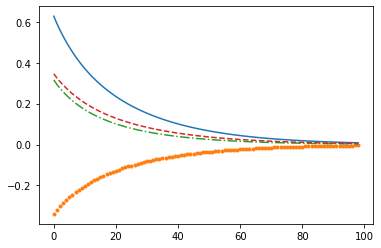

{'ns', 'n', 'c', 'a'} Initial impact on Y[o] from i shock for different s > 0-horizon
{'ns', 'n', 'c', 'a'} Initial impact on Y[o] from i shock different s>=0-horizon


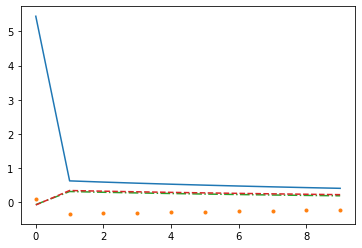

In [25]:
curlyYs[i].items() # for each output, we get the response

print(output_list, "Initial impact on Y[o] from i shock for different s-horizon")

plt.plot(curlyYs['r']['a'][1:round(T/3)])
plt.plot(curlyYs['r']['c'][1:round(T/3)],'.')
plt.plot(curlyYs['r']['n'][1:round(T/3)],'-.')
plt.plot(curlyYs['r']['ns'][1:round(T/3)],'--')

plt.show()

print(output_list, "Initial impact on Y[o] from i shock for different s > 0-horizon")

plt.plot(curlyYs['r']['a'][0:10])
plt.plot(curlyYs['r']['c'][0:10],'.')
plt.plot(curlyYs['r']['n'][0:10],'-.')
plt.plot(curlyYs['r']['ns'][0:10],'--')

print(output_list, "Initial impact on Y[o] from i shock different s>=0-horizon")



In [107]:
# Re-state shock list (i.e. endogenous inputs in Het Agent block)

shock_list = ['w', 'r', 'Div', 'Tax'] # Inputs to shock in the jacobian

print("input shock list", shock_list)

print("output list", output_list)

ss_for_hetinput

input shock list ['w', 'r', 'Div', 'Tax']
output list {'n', 'a', 'c', 'ns'}


{'div_rule': array([0.25952913, 0.39037867, 0.58720002, 0.88325488, 1.32857484,
        1.99841649, 3.00597929]),
 'pi_e': array([0.015625, 0.09375 , 0.234375, 0.3125  , 0.234375, 0.09375 ,
        0.015625]),
 'Tax': 0.027999999999999997,
 'tax_rule': array([0.25952913, 0.39037867, 0.58720002, 0.88325488, 1.32857484,
        1.99841649, 3.00597929]),
 'Div': 0.16666666666666663}

In [26]:
# In het_block class you'll find 
test = 0 # make sure this doesn't run 
if test == 1:
    def backward_iteration_fakenews(self, input_shocked, output_list, ssin_dict, ssout_list, Dss, Pi_T, 
                                    sspol_i, sspol_pi, sspol_space, T, h=1E-4, ss_for_hetinput=None):
        
        """Iterate policy steps backward T times for a single shock."""
        
        if self.hetinput is not None and input_shocked in self.hetinput_inputs:
            # if input_shocked is an input to hetinput, take numerical diff to get response
            din_dict = dict(zip(self.hetinput_outputs_order, 
                                utils.numerical_diff_symmetric(self.hetinput, ss_for_hetinput, {input_shocked: 1}, h)))
        else:
            # otherwise, we just have that one shock
            din_dict = {input_shocked: 1}

        # contemporaneous response to unit scalar shock [BACKWARD STEP -> SEE BELOW]
        curlyV, curlyD, curlyY = self.backward_step_fakenews(din_dict, output_list, ssin_dict, ssout_list, 
                                                             Dss, Pi_T, sspol_i, sspol_pi, sspol_space, h)
        
        # infer dimensions from this and initialize empty arrays
        curlyDs = np.empty((T,) + curlyD.shape)
        curlyYs = {k: np.empty(T) for k in curlyY.keys()}

        # fill in current effect of shock
        curlyDs[0, ...] = curlyD
        for k in curlyY.keys():
            curlyYs[k][0] = curlyY[k]

        # fill in anticipation effects
        for t in range(1, T):
            curlyV, curlyDs[t, ...], curlyY = self.backward_step_fakenews({k+'_p': v for k, v in curlyV.items()},
                                                    output_list, ssin_dict, ssout_list, 
                                                    Dss, Pi_T, sspol_i, sspol_pi, sspol_space, h)
            for k in curlyY.keys():
                curlyYs[k][t] = curlyY[k]

        return curlyYs, curlyDs
    

## Backward Iteration to build Fake News Matrix

### Single iteration for s = 0 and s =1,...,T horizons
Let's unpack this function a bit, keeping in mind that we are after aggregate outputs $\mathcal{Y}^{o,i}_s$  and distributions $\mathcal{D}^{i}_s$ 

The function `backward_iteration_fakenews` takes as an

--> input `input_shocked` (e.g. `'w'`) and the output list requested `output_list` (e.g. `{'n', 'a', 'c', 'ns'}`)  and calls on `backward_step_fakenews` to return `curlyV, curlyD, curlyY` for each of the s shock horizons we need to fill the columns of our fake-news matrix. 

--> outputs `curlyYs, curlyDs` for a particular input, which are then passed on as entries `curlyYs[i]` which is a dictionary with structure `{#output keys : #T shock distances}` to store T scalars and `curlyDs[i]` which is a `3D array [T,ns,ng] (over grid ns x nx)` to store T matrices for each input i.

For each input i, to fill out the s shock response for s = 0,...,T-1, it first computes the shock on impact s=0

`curlyV, curlyD, curlyY = self.backward_step_fakenews(din_dict, output_list, ss...)`

Initializes `curlyDs` as a `3D array [T,ns,ng] (over grid ns x nx)` to store given a row $\mathcal{D}^{i}_s$ and `curlyYs` as a dictionary `{#output keys : #T shock distances}` (for each output `k` in `curlyY.keys()` which are the `output_list` (e.g. `{'n', 'a', 'c', 'ns'}`), create a dictionary in a loop that has a T-size vector in each entry to store all aggregate $\mathcal{Y}^{o,i}_s$ for each output of interest. 

`curlyDs = np.empty((T,) + curlyD.shape)
 curlyYs = {k: np.empty(T) for k in curlyY.keys()}`
 
It is important to note here that while we need to generate a $\mathcal{Y}^{o,i}_s$ for every output per input, we only need to create $\mathcal{D}^{i}_s$ once per input. 

With this, we just need to fill in the outputs and distribution for s = 0 shock given our ns,nx `curlyD` and scalar stored in the dictionary entry `curlyY[k]` for each output.

`curlyDs[0, ...] = curlyD
 for k in curlyY.keys():
       curlyYs[k][0] = curlyY[k]`

We then fill in the s > 0 for s = 1,...T news shocks (the rest of the columns for the Fake News matrix)

`
for t in range(1, T):
    curlyV, curlyDs[t, ...], curlyY = self.backward_step_fakenews({k+'_p': v for k, v in curlyV.items()},
                                                    output_list, ssin_dict, ssout_list, 
                                                    Dss, Pi_T, sspol_i, sspol_pi, sspol_space, h)
    for k in curlyY.keys():
        curlyYs[k][t] = curlyY[k]`
        
Note that we are directly editing the s'th row of the `curlyD` matrix which is simply $\mathcal{D}^{i}_s$ , and then simply editing the nested dictionary of `curlyYs[k][t] = curlyY[k]` updating the s'th entry of the vector that lives in `curlyYs[k]` with the scalar in `curlyY[k]`, which is simply $\mathcal{Y}^{o,i}_s$. 

### Single Backward Step for each horizon s

To understand the difference between between s = 0 and s>0 we need to understand the function `backward_step_fakenews`, which has

--> input (1) `din_dict` e.g.  `{'w': 1}` for s = 0 or (2) `{k+'_p': v for k, v in curlyV.items()}` for and the output list requested `output_list` (e.g. `{'n', 'a', 'c', 'ns'}`)  

--> outputs `curlyV, curlyD, curlyY` 

Before going into detail on how this is done, we need to study numerical differentiation

### (Detour to) Numerical differentiation of Backward Step function 

The key step is the numerical differentiation of `back_step_fun` wrt `ssin_dict`

`shocked_outputs = {k: v for k, v in zip(self.all_outputs_order, utils.numerical_diff(self.back_step_fun, ssin_dict, din_dict...))}`
     
You can find the `numerical_diff(func, ssinputs_dict, shock_dict,...)` function in `utilities`, which calculates for our function `back_step_fun` with respect to `shock_dict` that we feed in, which is our `din_dict`. 

`f'(xss)*shock = (f(xss + h*shock) - f(xss))/h` 

In our case, we are after $d\mathbf{y}_{t}^{s}\equiv\mathbf{y}_{t}^{s}-\mathbf{y}_{ss}$ for $\mathbf{X}^{s}\equiv\mathbf{X}_{ss}+\mathbf{e}^{s}dx$ where the shock is a shift in the xss vector in the s position by a small factor h. 

`y'(xss)*dx = (y(xss + h*dx) - y(xss))/h`

Note this requires the following elements 

(1) `y=f(xss)` **policies in the steady state** `y_ss_list` fed as inputs or the algorithm will have to solve for it evaluating the function `back_step_fun` at with the *ss input dictionary* passed as an argument 

`y_ss_list = make_tuple(func(**ssinputs_dict))`

Note: In Python `**kwargs` will give you all keyword arguments except for those corresponding to a formal parameter as a `**dictionary` with the possibility of looping through keys

(2) `y(xss + h*dx)` **policies after shock** evaluating `back_step_fun` at the *shocked input dictionary* passed as an argument

`y_list = make_tuple(func(**shocked_inputs))`

(3) `xss + h*dx` **shocked inputs** dictionary which adds to the entries corresponding to each `k` key of the steady state dictionary `ssinputs_dict[k]` the term `h*shock` where `shock` is simply the entry corresponding to the key `k` in the `shock_dict` dictionary we fed to the function (i.e. I suspect looping through `k` keys alone would give let you do `{k: ssinputs_dict[k] + h * shock_dict[k] for k in shock_dict.keys()}` if they had the same number of entries, but do not quote me on that...

`shocked_inputs = {**ssinputs_dict, **{k: ssinputs_dict[k] + h * shock for k, shock in shock_dict.items()}}`

(4) `(y(xss + h*dx) - y(xss))/h` **numerical derivative** simply computes the rate of change for each element in `y_list` and `y_ss`. 

`dy_list = [(y - y_ss) / h for y, y_ss in zip(y_list, y_ss_list)]` 

### (Back to) Single Backward Step for each horizon s

#### Obtain `curlyV`: shocked outputs $d\mathbf{y}_{t}^{s}$ via numerical differentiation

The key step is obtaining  $d\mathbf{y}_{t}^{s}$ for a given output `k` create a dictionary with `v` entry corresponding to the k'th list produced by the numerical differentiation package, which itself returns how a particular output vector over the grid changes.  

$$ d\mathbf{y}_{0}^{s} = \mathbf{y}_{0}\left(\mathbf{X}^{s}\right)-\mathbf{y}_{ss}$$

`shocked_outputs = {k: v for k, v in zip(self.all_outputs_order, utils.numerical_diff(self.back_step_fun, ssin_dict, din_dict, h, ssout_list))}`

For a given s, we want to know how output stored `shocked_outputs` for `k` in `all_outputs_order` changes with the shock `y_ss_list` or the `v` which gives us the policy change $dy_0^s$ when only $x^s$ is changed for each output `k`

`curlyV = {k: shocked_outputs[k] for k in self.backward}`

#### Obtain `curlyY`: shocked outputs $\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss}$ via aggregation 

Given shocked outputs, for each output, compute

$$ \mathcal{Y}_{s}dx\equiv dY_{0}^{s}=\left(d\mathbf{y}_{0}^{s}\right)^{\prime}\mathbf{D}_{ss} $$ 

for which all we need is the steady state distribution, which is already given, and how the policies adjust. 

 `curlyY = {k: np.vdot(Dss, shocked_outputs[k]) for k in output_list}`

#### Obtain `curlyD`: shocked distribution $\mathcal{D}_{s}dx$ via transition

$$ \mathcal{D}_{s}dx\equiv d\mathbf{D}_{1}^{s}=\left(d\Lambda_{0}^{s}\right)^{\prime}\mathbf{D}_{ss} $$ 



Then have the change in output relative to SS policy. Note this is $d\mathbf{y}_{t}^{s}/\mathbf{y}_{ss} \equiv\mathbf{y}_{t}^{s}/\mathbf{y}_{ss}-1$

`pol_pi_shock = {k: -shocked_outputs[k]/sspol_space[k] for k in self.policy}`

And compute how the changes in the policy affect the distribution tomorrow given that we start from `Dss`  today. Note this is different from what you might be used to from the codes we've used before for computing the steady state, in which we only needed the left index and it's weight where the policy for each point on the grid was going to take you, as well as the initial distribution.

`Dnew = self.forward_step(D, Pi_T, sspol_i, sspol_pi)` 

In transition, for calculating $d\mathbf{D}_{1}^{s}$ we need to start from the steady state distribution `Dss`, and simply add the perturbation in relative to the steady state `pol_pi_shock`.

`curlyD = self.forward_step_shock(Dss, Pi_T, sspol_i, sspol_pi, pol_pi_shock)`

This step is probably the trickiest -- you can read more on the "SSJ" notes on Canvas.  In essence, to get the proportional change in $\frac{d\pi}{\pi_{ss}}$ we approximate it with minus the change in the policies -$\frac{dx\left(s,x_{-};\mathbf{X}^{s}\right)}{x_{ss}x\left(s,x_{-};X\right)}$. This is because $\pi$ is the probability of being sent down to the left grid point. So an increased policy function $x$ should imply a decrease in such probability $\pi$. 



In [183]:
x = 'm'
x = x +'_p'
x


'm_p'

In [ ]:
# In het_block class you'll find 
test = 0 # make sure this doesn't run 
if test == 1:
        def backward_step_fakenews(self, din_dict, output_list, ssin_dict, ssout_list, 
                               Dss, Pi_T, sspol_i, sspol_pi, sspol_space, h=1E-4):
        
        # din_dict = {input_shocked: 1} e.g. {'w': 1} or {k+'_p': v for k, v in curlyV.items()}
        
        # shock perturbs outputs : NUMERICAL DIFFERENTIATION of back_step_fun wrt ssin_dict
        shocked_outputs = {k: v for k, v in zip(self.all_outputs_order,
                                                utils.numerical_diff(self.back_step_fun, ssin_dict, din_dict, h,
                                                                     ssout_list))}
        curlyV = {k: shocked_outputs[k] for k in self.backward}

        # which affects the distribution tomorrow
        
        pol_pi_shock = {k: -shocked_outputs[k]/sspol_space[k] for k in self.policy}
        curlyD = self.forward_step_shock(Dss, Pi_T, sspol_i, sspol_pi, pol_pi_shock)

        # and the aggregate outcomes today
        curlyY = {k: np.vdot(Dss, shocked_outputs[k]) for k in output_list}

        return curlyV, curlyD, curlyY
    
    def numerical_diff(func, ssinputs_dict, shock_dict, h=1E-4, y_ss_list=None):
        """Differentiate function numerically via forward difference, i.e. calculate

        f'(xss)*shock = (f(xss + h*shock) - f(xss))/h

        for small h. (Variable names inspired by application of differentiating around ss.)

        Parameters
        ----------
        func            : function, 'f' to be differentiated
        ssinputs_dict   : dict, values in 'xss' around which to differentiate
        shock_dict      : dict, values in 'shock' for which we're taking derivative
                            (keys in shock_dict are weak subset of keys in ssinputs_dict)
        h               : [optional] scalar, scaling of forward difference 'h'
        y_ss_list       : [optional] list, value of y=f(xss) if we already have it

        Returns
        ----------
        dy_list : list, output f'(xss)*shock of numerical differentiation
        """
        # compute ss output if not supplied
        if y_ss_list is None:
            y_ss_list = make_tuple(func(**ssinputs_dict))

        # response to small shock: add h*shock to 
        shocked_inputs = {**ssinputs_dict, **{k: ssinputs_dict[k] + h * shock for k, shock in shock_dict.items()}}
        y_list = make_tuple(func(**shocked_inputs))

        # scale responses back up, dividing by h
        dy_list = [(y - y_ss) / h for y, y_ss in zip(y_list, y_ss_list)]

        return dy_list

    # Example of your usual forward step
    import numba
    @numba.njit
    def forward_policy(D, x_i, x_pi):
        Dend = np.zeros_like(D)
        for s in range(x_i.shape[0]):
            for x in range(x_i.shape[1]):
                # send pi(s,x) of the mass to gridpoint i(s,x)
                Dend[s, x_i[s,x]] = Dend[s, x_i[s,x]] + x_pi[s,x]*D[s,x]

                # send 1-pi(s,x) of the mass to gridpoint right above i(s,x)+1
                Dend[s, x_i[s,x]+1] = Dend[s, x_i[s,x]+1] + (1-x_pi[s,x])*D[s,x]

        return Dend

    @njit
    def forward_step_shock_1d(Dss, Pi_T, x_i_ss, x_pi_shock): # find the one without the missing input
        
        """forward_step_1d linearized wrt x_pi"""
        
        # first find effect of shock to endogenous policy
        nZ, nX = Dss.shape
        Dshock = np.zeros_like(Dss)
        for iz in range(nZ):
            for ix in range(nX):
                i = x_i_ss[iz, ix]
                dshock            = x_pi_shock[iz, ix] * Dss[iz, ix]
                Dshock[iz, i]     = Dshock[iz, i]     + dshock
                Dshock[iz, i + 1] = Dshock[iz, i + 1] - dshock

        # then apply exogenous transition matrix to update
        return Pi_T @ Dshock
    
    def forward_step_shock(self, Dss, Pi_T, pol_i_ss, pol_pi_ss, pol_pi_shock):
        """Forward_step linearized with respect to pol_pi"""
        if len(self.policy) == 1:
            p, = self.policy
            return utils.forward_step_shock_1d(Dss, Pi_T, pol_i_ss[p], pol_pi_shock[p])
        elif len(self.policy) == 2:
            p1, p2 = self.policy
            return utils.forward_step_shock_2d(Dss, Pi_T, pol_i_ss[p1], pol_i_ss[p2],
                                               pol_pi_ss[p1], pol_pi_ss[p2], pol_pi_shock[p1], pol_pi_shock[p2])
        else:
            raise ValueError(f"{len(self.policy)} policy variables, only up to 2 implemented!")

Each $\mathcal{Y}^{o,i}$ is a length-$T$ vector that characterizes the change in output $o$ given from news of a shock to input $i$ at each horizon $t$, holding the distribution fixed at the steady state. For instance, we can look at $\mathcal{Y}^{C,r}$.

In [27]:
len(curlyYs['r']['c'])

300

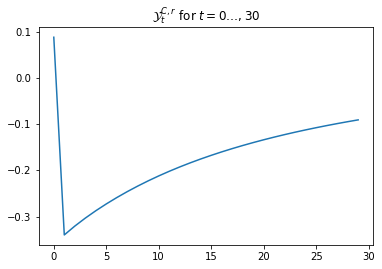

In [28]:
plt.plot(curlyYs['r']['c'][:30])
plt.title(r'$\mathcal{Y}^{C,r}_t$ for $t=0\ldots,30$');



This is fairly easy to interpret: if the shock to the ex-post real interest rate $r$ occurs *today*, at a horizon of 0, then we *increase* consumption, since we have more resources from the interest income (an **income effect**) and real interest rates going forward are unchanged.

But if the shock to $r$ is expected to arrive at a horizon greater than zero, we *decrease* consumption thanks to a **substitution effect**: we want to save more to earn the higher $r$ in the future. This effect is largest when the shock to $r$ is coming immediately in the future, at a horizon of 1, and shrinks as the shock to $r$ comes at more distant horizons.

By contrast, each $\mathcal{D}^i$ is an array with dimension of $T$ times the dimensions of the state space (here $7\times 500$, corresponding to 7 exogenous states and 500 asset gridpoints). For each $t$, this gives the first-order perturbation to the distribution of agents in the next period caused by the policy effect of the shock to input $i$ expected in $t$ periods.

For instance:

In [36]:
print(curlyDs['r'].shape)
print(curlyDs['r'][0,...].shape)
ns = len(curlyDs['r'][0,...])
ns

(300, 7, 500)
(7, 500)


7

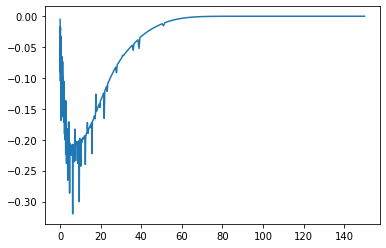

In [86]:
# Increase in r, s = 0 shock effects across the distribution

plt.plot(ss['a_grid'][:500], curlyDs['r'][0,:,:500].sum(axis=0).cumsum())

plt.show()



is the **first-order effect of an $r$ shock today on the distribution tomorrow**.

Aggregating these $\mathcal{D}^r$ against the asset grid, we get the effect on tomorrow's aggregate assets, which also happens to be $\mathcal{Y}^{A,r}$. Let's plot these at all horizons from 0 to 30 and verify that they give the same answer: (let the input change be $dr^s$)

$$dA_{1}dr^s\equiv\int a_{-}dD_{1}\left(s,a_{-}\right)dr^s=\left(\mathbf{a}_{grid}\right)^{\prime}\mathbf{dD}_{1}^{s}dr^s = \mathcal{Y}^{A,r} dr^s$$

In essence this let's you verify that 

$$\mathcal{F}_{0,:}=\left[\begin{array}{ccccc}
\mathcal{Y}_{0} & \mathcal{Y}_{1} & \mathcal{Y}_{2} & \ldots & \mathcal{Y}_{T-1}\end{array}\right]$$

which is also the first row of the Jacobian. 

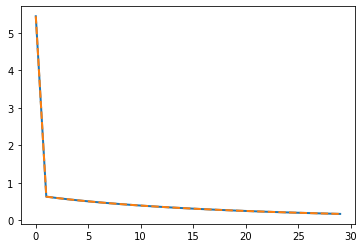

In [89]:
asset_effects = np.sum(ss['a_grid']*curlyDs['r'], axis=(1,2))
plt.plot(asset_effects[:30], linewidth=2)
plt.plot(curlyYs['r']['a'][:30], '--', linewidth=2);

Again, there is a distinction between a horizon of 0 and all other horizons: if the shock to $r$ occurs today, then the **interest income means that we have lots more to save in assets**, while if the shock to $r$ is occuring in the future, then **there's just the substitution effect**, which weakens with horizon.

Note that step 1 took about three-quarters of a second (on the laptop used to run this notebook). This is by far the costliest step of the fake news algorithm as currently implemented, since it involves a separate length-$T$ backward iteration for each shocked input.

**Step 2 of fake news algorithm: (transpose) forward iteration.** Now, we get the $\mathcal{P}^o_u$ for each output $o$ and $T-1$ values of $u$. To do so, we feed the steady-state values of each $o$ at each point on the grid, as well as variables characterizing the steady-state transition matrix over exogenous (`Pi`) and endogenous (`sspol_i` and `sspol_pi`) states, into the `forward_iteration_fakenews` function.

 Calculate the $\left(T-1\right)n_{g}\times1$ expectation vectors $\mathcal{E}_{t}\equiv\left(\Lambda_{ss}\right)^{t}\mathbf{y}_{ss}$ from the recursion

$$\mathcal{E}_{t}=\Lambda_{ss}\mathcal{E}_{t-1},\quad\mathcal{E}_{0}=\mathbf{y}_{ss}$$

In [90]:
%%time
curlyPs = {}
for o in output_list:
    curlyPs[o] = household.forward_iteration_fakenews(ss[o], Pi, sspol_i, sspol_pi, T-1)

CPU times: user 53.7 ms, sys: 24.9 ms, total: 78.5 ms
Wall time: 101 ms


In [ ]:
test = 0
if test == 1:
    def forward_iteration_fakenews(self, o_ss, Pi, pol_i_ss, pol_pi_ss, T):
        
        # o_ss is the output optimal policy in the steady state
        """Iterate transpose forward T steps to get full set of curlyPs for a given outcome.
        
        Note we depart from definition in paper by applying the demeaning operator in addition to Lambda
        at each step. This does not affect products with curlyD (which are the only way curlyPs enter
        Jacobian) since perturbations to distribution always have mean zero. It has numerical benefits
        since curlyPs now go to zero for high t (used in paper in proof of Proposition 1).
        """
        curlyPs = np.empty((T,) + o_ss.shape)
        curlyPs[0, ...] = utils.demean(o_ss)
        for t in range(1, T):
            curlyPs[t, ...] = utils.demean(self.forward_step_transpose(curlyPs[t-1, ...], Pi, pol_i_ss, pol_pi_ss))
        return curlyPs
    
    def forward_step_transpose(self, D, Pi, pol_i, pol_pi):
        """Transpose of forward_step (note: this takes Pi rather than Pi_T as argument!)"""
        if len(self.policy) == 1:
            p, = self.policy
            return utils.forward_step_transpose_1d(D, Pi, pol_i[p], pol_pi[p])
        elif len(self.policy) == 2:
            p1, p2 = self.policy
            return utils.forward_step_transpose_2d(D, Pi, pol_i[p1], pol_i[p2], pol_pi[p1], pol_pi[p2])
        else:
            raise ValueError(f"{len(self.policy)} policy variables, only up to 2 implemented!")

    @njit
    def forward_step_transpose_1d(D, Pi, x_i, x_pi):
        """Transpose of forward_step_1d"""
        # first update using exogenous transition matrix
        D = Pi @ D

        # then update using (transpose) endogenous policy
        nZ, nX = D.shape
        Dnew = np.zeros_like(D)
        for iz in range(nZ):
            for ix in range(nX):
                i = x_i[iz, ix]
                pi = x_pi[iz, ix]
                Dnew[iz, ix] = pi * D[iz, i] + (1-pi) * D[iz, i+1]
        return Dnew

Note that this is much faster than the backward iteration. This is because the "transpose" forward iteration is just sparse linear algebra using the steady-state transition matrix; it can be implemented independent of the individual model, and we have done so efficiently.

Each $\mathcal{P}^o$ has dimension of $T-1$ times the dimension of the state space.

In [92]:
print(curlyPs['a'].shape)
print(curlyPs['a'][1,...].shape)

(299, 7, 500)
(7, 500)


$\mathcal{P}_u^o$ gives the effect that a perturbation to the distribution of agents will have on aggregate output $o$, $u$ periods later.

For example, $\mathcal{D}_0^r$, which we just discussed, gives the effect on the distribution at time 1 from a time-0 shock to the ex-post real interest rate $r$, is a certain perturbation to the distribution. Taking the vector dot product of this with $\mathcal{P}_u^A$ for $u=0,\ldots,29$, we can trace out the persistent effect of this shock on aggregate assets from time 1 to time 30. 

$$
\mathcal{F}_{:,0}=\left[\begin{array}{c}
\mathcal{Y}_{0}\\
\mathcal{E}_{0}^{\prime}\mathcal{D}_{0}\\
\mathcal{E}_{1}^{\prime}\mathcal{D}_{0}\\
\vdots\\
\mathcal{E}_{T-2}^{\prime}\mathcal{D}_{0}
\end{array}\right]$$

Let's plot this effect, and compare to the impulse response from a time-0 shock in the Jacobian we've already calculated to be sure we're correct:


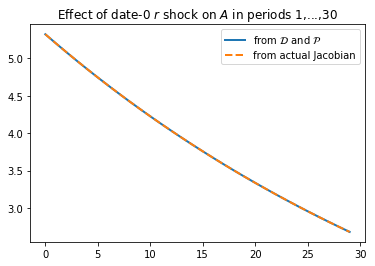

In [22]:
persistent_asset = np.array([np.vdot(curlyDs['r'][0,...],
                                     curlyPs['a'][u,...]) for u in range(30)])
plt.plot(persistent_asset, linewidth=2, label=r'from $\mathcal{D}$ and $\mathcal{P}$')
plt.plot(Js['A']['r'][1:31,0], '--', linewidth=2, label='from actual Jacobian')
plt.legend()
plt.title(f'Effect of date-0 $r$ shock on $A$ in periods 1,...,30');

**Step 3 of fake news algorithm: combine everything to make the fake news matrix for each output-input pair.** For each output-input pair $(o,i)$, step 3 is to build the "fake news matrix" $\mathcal{F}^{o,i}$, with $\mathcal{Y}^{o,i}$ in row $t=0$, and the product $(\mathcal{P}^o)(\mathcal{D}^i)'$ in rows $t=1,\ldots,T-1$. We can quickly do so:

In [93]:
%%time
Fs = {o.upper(): {} for o in output_list}
for o in output_list:
    for i in shock_list:
        F = np.empty((T,T))
        F[0, ...] = curlyYs[i][o] # first row should just have the impact Jacobians
        F[1:, ...] = curlyPs[o].reshape(T-1, -1) @ curlyDs[i].reshape(T, -1).T # other rows have dot(E,dD)
        Fs[o.upper()][i] = F

CPU times: user 508 ms, sys: 273 ms, total: 781 ms
Wall time: 400 ms


Relative to the description in the paper, we take the transpose of $\mathcal{D}$, not of $\mathcal{P}$, since our convention in the code has the time dimension first (rather than last, as in the paper).

Also note the two `reshape` commands: these collapse the multiple dimensions corresponding to the state space into a single dimension (with length equal to the size of the state space), which matches the notation in the paper and allows us to multiply the two matrices along this dimension.

Note that this is the second costliest step of the algorithm, taking about a quarter of a second (on this laptop).

One way to think about what this step does is that there are $n_o\times n_i = 16$ fake news matrices, each with $T\times T = 90,000$ entries, so there are $16\times 90,000 = 1,440,000$ fake news matrix entries overall. For *each* of these entries except in the first row, we need to do a vector dot product of a $\mathcal{P}_t$ and a $\mathcal{D}_s$, each of which has dimensionality equal to the state space. In principle, this is quite computationally intensive! But since we structure it as one big matrix multiplication for each pair of $o$ and $i$, and matrix multiplication is a generic operation that is extremely efficiently implemented under the hood in many numerical packages, it's easy for this step to be fast.

Recall that each column $s$ of the ordinary Jacobian gives the impulse response to a news shock at date 0 about date $s$. Each column $s$ of the fake news matrix, by contrast, gives us the response to the corresponding "fake news" shock, where at date 1 the news is revealed to have been fake (and the shock does not actually happen).

To see the difference, compare the consumption impulse response to a true news shock about date-1 wages (which we'll get from the Jacobian we already calculated) to a fake news shock about date-1 wages.

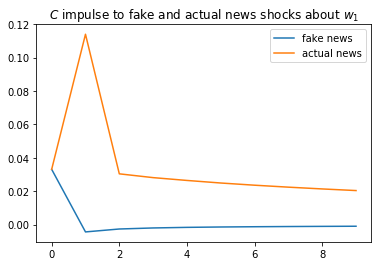

In [24]:
plt.plot(Fs['C']['w'][:10, 1], label='fake news')
plt.plot(Js['C']['w'][:10, 1], label='actual news')
plt.title(r'$C$ impulse to fake and actual news shocks about $w_1$')
plt.legend();

###### Note: Key intuition for why Jacobians are built recursively from Fake News matrices

Consumption is the same in both cases in period 0, since at that point households have the same information about the "news" of higher wages at date 1. But then consumption spikes and stays elevated when the news of the wage shock is actually realized at date 1 ("actual"). *In the fake news case, by contrast, no increase in wages is received, and consumption falls below its steady-state level as households rebuild their balance sheets after they dissaved at date 0 in response to the fake news.*

Conceptually, the response to the actual news shock has two parts. *First, there is the impulse from anticipation at date 0, which is the same for actual and fake news shocks.* Then, there is the impulse to *actually getting* the wage increase at date 1. ***This* impulse is the same as the impulse to an unanticipated shock at date 0 (shifted over to be at date 1).**

This gives rise to a strategy for getting the second column of the Jacobian, the response to an actual news shock for date 1: add together the second column of the fake news matrix with the shifted first column of the Jacobian. Let's verify that this works.

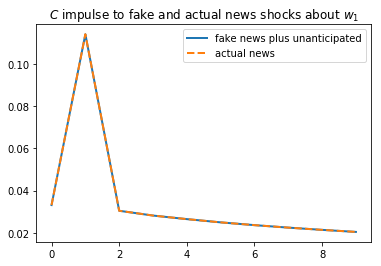

In [25]:
impulse = Fs['C']['w'][:10, 1].copy() # start with fake news impulse
impulse[1:10] += Js['C']['w'][:9, 0]   # add unanticipated impulse, shifted by 1

plt.plot(impulse, label='fake news plus unanticipated', linewidth=2)
plt.plot(Js['C']['w'][:10, 1], '--', label='actual news', linewidth=2)
plt.title(r'$C$ impulse to fake and actual news shocks about $w_1$')
plt.legend();

Success!

This insight, suitably generalized, is the basis of the recursion used in the final step to go from the fake news matrix to the Jacobian.

**Step 4 of fake news algorithm: recursively convert fake news matrices to actual Jacobian matrices.** Equation (30) in the paper shows that the following recursion relates the actual Jacobian $\mathcal{J}_{t,s}$ to the fake news matrix $\mathcal{F}_{t,s}$ (for any pair of outputs and inputs):

$$
\mathcal{J}_{t,s} =
\begin{cases}
\mathcal{F}_{t,s} & t=0\text{ or }s=0 \\
\mathcal{F}_{t,s} + \mathcal{J}_{t-1,s-1} & \text{otherwise}
\end{cases} \tag{30}
$$

Conceptually, this recursion builds on the idea that we discussed for step 3: **representing actual impulses to news shocks as sums of fake news matrix entries and unanticipated shocks.**

Let's implement this recursion to get our results. (Before we start, we'll save the Jacobian dict we already calculated to the name `Js_original` to avoid overwriting it along the way.)

In [94]:
%%time
Js_original = Js
Js = {o.upper(): {} for o in output_list}
for o in output_list:
    for i in shock_list:
        # implement recursion (30): start with J=F and accumulate terms along diagonal
        J = Fs[o.upper()][i].copy()
        for t in range(1, J.shape[1]):
            J[1:, t] = J[1:, t] +  J[:-1, t-1]
        Js[o.upper()][i] = J

CPU times: user 28 ms, sys: 6.51 ms, total: 34.5 ms
Wall time: 36.1 ms


Success! Now we have the Jacobian.

This is the fastest and easiest of the steps. It reveals just how useful the fake news matrix is in obtaining the Jacobian.

Let's verify that the Jacobians in `Js` are *exactly* the same as that returned earlier by `.jac`, without even epsilon difference. This is only possible because we just followed the exact same steps as the `.jac` method.

In [95]:
for o in output_list:
    for i in shock_list:
        assert np.array_equal(Js[o.upper()][i], Js_original[o.upper()][i])

## 2 Not using the fake news algorithm? Costlier, direct approach
Suppose that we wanted to get the same Jacobians without using the fake news algorithm. The "direct" approach discussed in the paper (which could less charitably be called "brute force") uses numerical differentiation to do this.

The idea is to run `household.td`, which calculates the nonlinear household impulse response to a given shock, to a small version of each shock (multiplied by $h$) at each date $s$ from 0 up to $T$. We take the results, and rescaling by $h^{-1}$ we get each column $s$ of the Jacobian.

One crucial caveat is that since the numerically calculated steady state is not exactly a fixed point of backward or forward iteration, applying `household.td` without any shocks to the steady state does not return exactly the steady state. This numerical error can become quite significant in calculating the Jacobian when we blow it up by $h^{-1}$. We address this below in a simple way: first running `household.td` without any shocks, and then subtracting all the results by this to get the numerical derivative.

Below we differentiate with respect to only a single input, $r$, to avoid making the notebook run for too long.

In [96]:
%%time
T = 300
Js_direct = {}
short_shock_list = ('r')
h = 1E-4

Js_direct = {o.upper(): {i: np.empty((T, T)) for i in short_shock_list} for o in output_list}

# run td once without any shocks to get paths to subtract against
# (better than subtracting by ss since ss not exact)
# monotonic=True lets us know there is monotonicity of policy rule, makes TD run faster
# .td requires at least one input 'shock', so we put in steady-state w
td_noshock = household.td(ss, w=np.full(T, ss['w']), monotonic=True)

for i in short_shock_list:
    # simulate with respect to a shock at each date up to T
    for t in range(T):
        td_out = household.td(ss, **{i: ss[i]+h*(np.arange(T) == t)})
        
        # store results as column t of J[o][i] for each outcome o
        for o in output_list:
            Js_direct[o.upper()][i][:, t] = (td_out[o.upper()] - td_noshock[o.upper()])/h

CPU times: user 1min 6s, sys: 1.22 s, total: 1min 8s
Wall time: 1min 8s


We see that this took about 70 seconds. Since almost all the work is done separately for each shock, with all 4 input variables in `shock_list` this would take about 280 seconds.

Compare this to the time needed to get the Jacobian using our fake news algorithm, which is around one second:

In [29]:
%time _ = household.jac(ss, T, shock_list)

CPU times: user 1.15 s, sys: 42.7 ms, total: 1.19 s
Wall time: 974 ms


Hence, the extra time cost of the "direct" approach to getting the Jacobian, as we mention in the paper, is roughly a factor of $T=300$. Why? In the fake news algorithm, we did a single full backward iteration in step 1, whereas in the direct algorithm, we do $T$ full backward iterations. This dominates the running time and is primarily responsible for the factor-of-$T$ difference.

(Aside than this, the fake news algorithm has the extra steps 3 and 4, but makes up for it since its transpose forward iteration in step 2 is far, far faster than the $T$ nonlinear forward iterations in the direct approach.)

**Comparing results.**
Let's make sure that we have the same results from the fake news and direct algorithms by plotting some of the columns of the Jacobians. Let's look at the consumption response to real interest rate shocks.

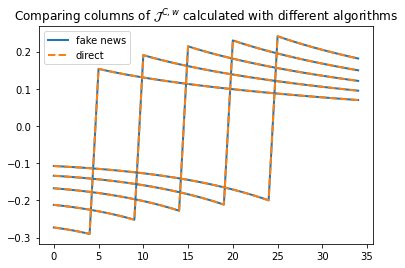

In [97]:
columns = (5, 10, 15, 20, 25)
l1, l2 = 'fake news', 'direct'
for col in columns:
    plt.plot(Js['C']['r'][:35, col], label=l1, linewidth=2, color='C0')
    plt.plot(Js_direct['C']['r'][:35, col], label=l2, linestyle='--', linewidth=2, color='C1')
    l1, l2 = '_nolegend_', '_nolegend_' # suppress extra legends
plt.title('Comparing columns of $\mathcal{J}^{C,w}$ calculated with different algorithms')
plt.legend()
plt.show()

A perfect match! This is one way to validate that the fake news algorithm gives the correct Jacobian.

Of course, the two do not give *numerically* identical results - although they are visually identical, and identical for practical purposes - since the underlying numerical differentiation is not infinitesimal and thus is affected by nonlinearities. It turns out that the fake news algorithm is more accurate than the direct algorithm in this regard, since it enforces linearity in the forward iteration and does a separate numerical differentiation at each step in the backward iteration, whereas the nonlinearities pile up in the direct algorithm.

Note from Martin: Some Python functions that might come in handy



In [193]:
#The *args will give you all function parameters as a *tuple:

def foo(*args):
    for a in args:
        print(a)        

foo(1)
1

foo(1,2,3)
1
2
3

# The **kwargs will give you all keyword arguments except for those corresponding 
# to a formal parameter as a **dictionary with the possibility of looping thorugh keys

def bar(**kwargs):
    for a in kwargs:
        print(a, kwargs[a])  

bar(name='one', age=27) 
# age 27
# name one

# The zip commad joins two typles together
a = ("John", "Charles", "Mike")
b = ("Jenny", "Christy", "Monica")

x = zip(a, b)

print(tuple(x))

1
1
2
3
name one
age 27
(('John', 'Jenny'), ('Charles', 'Christy'), ('Mike', 'Monica'))
